In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, losses
import re 
import string 
import matplotlib.pyplot as plt

In [2]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
data_dir = "data"

In [5]:
raw_training = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/train',
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=seed
)
raw_validation = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/train',
    batch_size=32,
    validation_split = 0.2,
    subset="validation",
    seed=seed,
)
raw_test = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/test',
    batch_size=32,
    seed=seed
)

Found 5000 files belonging to 2 classes.
Using 4000 files for training.
Found 5000 files belonging to 2 classes.
Using 1000 files for validation.
Found 5000 files belonging to 2 classes.


In [7]:
for text, label in raw_training.take(1):
    for i in range(2):
        print(label[i])
        print(text[i])

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(b"There is no denying that Ealing comedies are good, but for me this film stands out as one of the best.<br /><br />The basic premise of the film is that a small part of Pimlico in London is discovered to be part of Burgundy, not the UK. We then follow the lives of the residents in their battle to keep the treasure found after the bomb explodes, and keep out the black market traders who soon realise that being exempt from UK law, rationing does not exist. When they become prisoners in their own street because the government has decided to close the boarder we see them fight back against the system.<br /><br />They are forced to ration water and food in their stand for what is right. In fact becoming worse off than they were before it all started, that's where the moral comes in. It's when they loose all the food that they think they are beaten and call for a surrender, only to have the whole of London respond to their plight by sending food

In [9]:
max_token = 10000
def custom_standardaziation(input_data):
    lowercase = tf.strings.lower(input_data)
    stripped_html = tf.strings.regex_replace(lowercase,'<br />',' ')
    replaced = tf.strings.regex_replace(
        stripped_html,
        '[%s]' % re.escape(string.punctuation),
        ''
    )
    return replaced

vectorization_layer = layers.TextVectorization(
    standardize=custom_standardaziation,
    max_tokens=max_token,
    output_sequence_length=250,
)

In [17]:
train_text = raw_training.map(lambda x,y :x)
vectorization_layer.adapt(train_text)
print(len(vectorization_layer.get_vocabulary()))

10000


In [35]:
def vectorizatin_text_function(text,lable_ip):
    text = tf.expand_dims(text,-1)
    return vectorization_layer(text),lable_ip

text_batch, lable_batch = next(iter(raw_training))
frist_text, frist_label = text_batch[0], lable_batch[0]

# Show the raw data
print(f"Review:\n{frist_text}")
print(f"\nLabel: {raw_training.class_names[frist_label]}")
# Show the vectorized data
print(f"\nVectorized review\n{vectorizatin_text_function(frist_text, frist_label)}")

Review:
b'It wasn\'t the most pointless animation film experience ever, but it certainly can\'t be admired as much as it tries to be good. Combining Dreamworks animation and computer graphics, this is the story of a mustang, later named Spirit (Matt Damon, providing the first person narration), and his journey through across the frontiers of the Old West. Basically he is born free amongst all the other horses in the beautiful countryside, then he is kidnapped to be used as a saddle horse, he manages to throw off all who try to ride him. However when he escapes his cage, along with Little Creek (Daniel Studi), the two of them form a friendship, oh, and he obviously has a thing for Little Creek\'s female horse. In the end, after a few more escapes, being chased by The Colonel (James Cromwell) and his men, and making a final big leap across a gorge, Little Creek lets Spirit go, and he also releases his female horse, and they run home to their countryside and fellow horses. Also starring C

In [37]:
train_db = raw_training.map(vectorizatin_text_function)
validation_db = raw_validation.map(vectorizatin_text_function)
test_db = raw_test.map(vectorizatin_text_function)

In [40]:
AUTOTUNE = tf.data.AUTOTUNE
train_db = train_db.cache().prefetch(buffer_size=AUTOTUNE)
validation_db = validation_db.cache().prefetch(buffer_size=AUTOTUNE)
test_db = test_db.cache().prefetch(buffer_size=AUTOTUNE)

In [42]:
Embeddingdimension = 16
model = tf.keras.Sequential([
    layers.Embedding(max_token,Embeddingdimension),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1,activation='softmax')
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 16)          160000    
                                                                 
 global_average_pooling1d_1   (None, 16)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 160,017
Trainable params: 160,017
Non-trainable params: 0
_________________________________________________________________


In [44]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=['accuracy'])

In [49]:
history = model.fit(
    train_db,
    validation_data= validation_db,
    epochs=25,
    verbose=2
)

Epoch 1/25
125/125 - 0s - loss: 0.6803 - accuracy: 0.4938 - val_loss: 0.6739 - val_accuracy: 0.5250 - 282ms/epoch - 2ms/step
Epoch 2/25
125/125 - 0s - loss: 0.6600 - accuracy: 0.4938 - val_loss: 0.6516 - val_accuracy: 0.5250 - 269ms/epoch - 2ms/step
Epoch 3/25
125/125 - 0s - loss: 0.6311 - accuracy: 0.4938 - val_loss: 0.6238 - val_accuracy: 0.5250 - 268ms/epoch - 2ms/step
Epoch 4/25
125/125 - 0s - loss: 0.5973 - accuracy: 0.4938 - val_loss: 0.5942 - val_accuracy: 0.5250 - 252ms/epoch - 2ms/step
Epoch 5/25
125/125 - 0s - loss: 0.5617 - accuracy: 0.4938 - val_loss: 0.5655 - val_accuracy: 0.5250 - 253ms/epoch - 2ms/step
Epoch 6/25
125/125 - 0s - loss: 0.5265 - accuracy: 0.4938 - val_loss: 0.5387 - val_accuracy: 0.5250 - 267ms/epoch - 2ms/step
Epoch 7/25
125/125 - 0s - loss: 0.4927 - accuracy: 0.4938 - val_loss: 0.5140 - val_accuracy: 0.5250 - 236ms/epoch - 2ms/step
Epoch 8/25
125/125 - 0s - loss: 0.4607 - accuracy: 0.4938 - val_loss: 0.4917 - val_accuracy: 0.5250 - 253ms/epoch - 2ms/step


In [51]:
loss, accuracy = model.evaluate(test_db)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

157/157 [==============================] - 6s 37ms/step - loss: 0.3626 - accuracy: 0.5000
Loss: 0.36260655522346497
Accuracy: 0.5


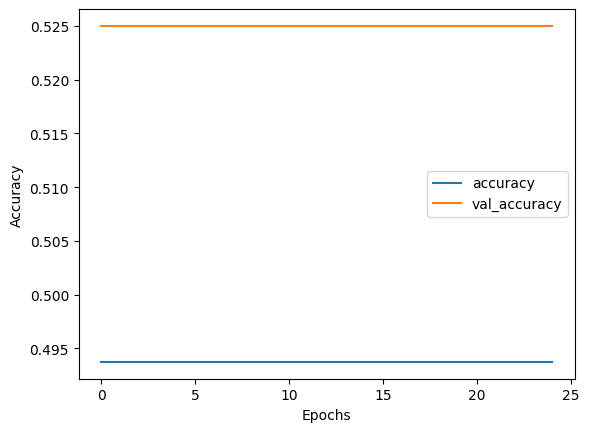

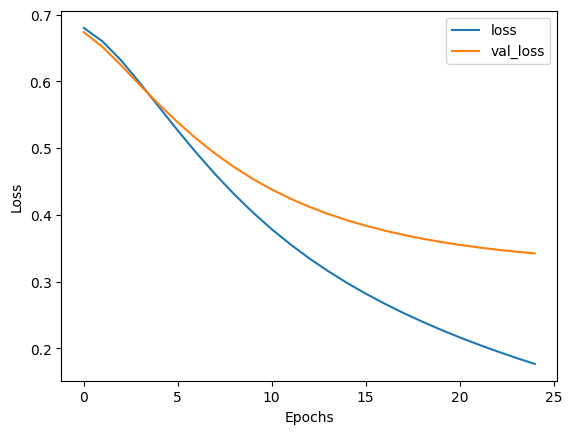

In [52]:
def plot_metrics(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric.title())
    plt.legend([metric, f'val_{metric}'])
    plt.show()
    
plot_metrics(history, "accuracy")
plot_metrics(history, "loss")

In [58]:
# Make a new sequential model using the vectorization layer and the model you just trained.
export_model = tf.keras.Sequential([
  vectorization_layer,
  model]
)

# Compile the model
export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)
export_model.save("savemodel/")

INFO:tensorflow:Assets written to: savemodel/assets


In [57]:
examples = ['this movie was very, very good', 'quite ok', 'the movie was not bad', 'bad', 'negative disappointed bad scary', 'this movie was stupid']

results = export_model.predict(examples, verbose=False)

for result, example in zip(results, examples):
    print(f'Result: {result[0]:.3f},   Label: {int(np.round(result[0]))},   Review: {example}')

Result: 1.000,   Label: 1,   Review: this movie was very, very good
Result: 1.000,   Label: 1,   Review: quite ok
Result: 1.000,   Label: 1,   Review: the movie was not bad
Result: 1.000,   Label: 1,   Review: bad
Result: 1.000,   Label: 1,   Review: negative disappointed bad scary
Result: 1.000,   Label: 1,   Review: this movie was stupid
